<a href="https://colab.research.google.com/github/Rifath-Mahmud/CVPR/blob/main/CNN_V2_FMNIST_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


cuda


In [79]:
data_folder = '~/data/MNIST'

# Load train data
mnist_train = datasets.FashionMNIST(root=data_folder, train=True, download=True)
tr_images = mnist_train.data
tr_targets = mnist_train.targets

# Load test data
mnist_test = datasets.FashionMNIST(root=data_folder, train=False, download=True)
te_images = mnist_test.data
te_targets = mnist_test.targets

print("Train images:", tr_images.shape, "\tTrain labels:", tr_targets.shape)
print("Test images: ", te_images.shape,  "\tTest labels: ",  te_targets.shape)


Train images: torch.Size([60000, 28, 28]) 	Train labels: torch.Size([60000])
Test images:  torch.Size([10000, 28, 28]) 	Test labels:  torch.Size([10000])


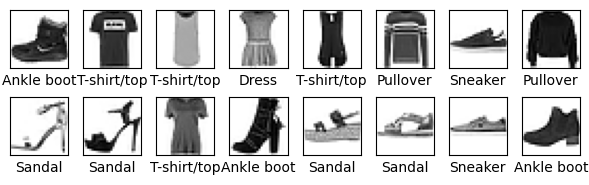

In [80]:
ROWS, COLS = 2 , 8
fig, axes = plt.subplots(ROWS, COLS, figsize=(6, 2))
for i, ax in enumerate(axes.flat):
    ax.imshow(tr_images[i], cmap="gray_r")
    ax.set_xlabel(mnist_train.classes[ tr_targets[i].item() ])
    ax.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

In [81]:
class MNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255.0
        x = x.view(-1, 1, 28, 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        return self.x[ix], self.y[ix]

    def __len__(self):
        return len(self.x)


In [82]:
train = MNISTDataset(tr_images, tr_targets)
trn_dl = DataLoader(train, batch_size=32, shuffle=True)

test = MNISTDataset(te_images, te_targets)
te_dl = DataLoader(test, batch_size=32, shuffle=False)

In [83]:
from torch.optim import Adam

def get_model():
    model = nn.Sequential(
                nn.Conv2d(1,64,3),
                nn.MaxPool2d(2),
                nn.ReLU(),

                nn.Conv2d(64,128,3),
                nn.MaxPool2d(2),
                nn.ReLU(),

                nn.Flatten(),
                nn.Linear(3200, 256),
                nn.ReLU(),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, 10)
            ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer


In [84]:
from torchsummary import summary
model, loss_fn, optimizer = get_model()
summary(model, input_size=(1,28,28));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]             640
         MaxPool2d-2           [-1, 64, 13, 13]               0
              ReLU-3           [-1, 64, 13, 13]               0
            Conv2d-4          [-1, 128, 11, 11]          73,856
         MaxPool2d-5            [-1, 128, 5, 5]               0
              ReLU-6            [-1, 128, 5, 5]               0
           Flatten-7                 [-1, 3200]               0
            Linear-8                  [-1, 256]         819,456
              ReLU-9                  [-1, 256]               0
           Linear-10                  [-1, 128]          32,896
             ReLU-11                  [-1, 128]               0
           Linear-12                   [-1, 10]           1,290
Total params: 928,138
Trainable params: 928,138
Non-trainable params: 0
-------------------------------

In [85]:
def train_batch(x, y, model, loss_fn, optimizer):
    model.train()
    optimizer.zero_grad()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    return batch_loss.item()

@torch.no_grad()
def batch_accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()


def train_one_epoch(data_loader, model, loss_fn, optimizer):
    epoch_losses, epoch_accuracies = [], []
    for batch in data_loader:
        x, y = batch
        x, y = x.to(device), y.to(device)   # move to device here
        batch_loss = train_batch(x, y, model, loss_fn, optimizer)
        epoch_losses.append(batch_loss)
        epoch_accuracies.extend(batch_accuracy(x, y, model))
    return np.array(epoch_losses).mean(), np.array(epoch_accuracies).mean()


@torch.no_grad()
def validation(data_loader, model, loss_fn):
    val_losses, val_accuracies = [], []
    model.eval()
    for x, y in data_loader:
        x, y = x.to(device), y.to(device)   # move to device here
        prediction = model(x)
        val_losses.append(loss_fn(prediction, y).item())
        val_accuracies.extend(batch_accuracy(x, y, model))
    return np.array(val_losses).mean(), np.array(val_accuracies).mean()


In [86]:
## Training Loop ###
losses, accuracies = [], []
val_losses, val_accuracies = [], []
training_epoch = 10

for epoch in range(training_epoch):
  epoch_loss, epoch_accuracy = train_one_epoch(trn_dl,model,loss_fn,optimizer)
  losses.append(epoch_loss)
  accuracies.append(epoch_accuracy)

  v_loss, v_acc =  validation(te_dl,model,loss_fn)
  val_losses.append(v_loss)
  val_accuracies.append(v_acc)

  print(f"Epoch [{epoch + 1}/{training_epoch}]"
        f" | Train Loss: {epoch_loss:.4f} | Train Accuracy: {epoch_accuracy*100:.2f}%"
        f" | Val Loss: {v_loss:.4f} | Val Accuracy: {v_acc*100:.2f}%")

Epoch [1/10] | Train Loss: 0.4717 | Train Accuracy: 83.60% | Val Loss: 0.3375 | Val Accuracy: 87.60%
Epoch [2/10] | Train Loss: 0.2937 | Train Accuracy: 90.21% | Val Loss: 0.3341 | Val Accuracy: 87.86%
Epoch [3/10] | Train Loss: 0.2455 | Train Accuracy: 91.90% | Val Loss: 0.2832 | Val Accuracy: 89.70%
Epoch [4/10] | Train Loss: 0.2099 | Train Accuracy: 93.22% | Val Loss: 0.2477 | Val Accuracy: 91.20%
Epoch [5/10] | Train Loss: 0.1834 | Train Accuracy: 94.25% | Val Loss: 0.2600 | Val Accuracy: 90.64%
Epoch [6/10] | Train Loss: 0.1587 | Train Accuracy: 95.10% | Val Loss: 0.2640 | Val Accuracy: 91.46%
Epoch [7/10] | Train Loss: 0.1382 | Train Accuracy: 95.96% | Val Loss: 0.2534 | Val Accuracy: 91.92%
Epoch [8/10] | Train Loss: 0.1192 | Train Accuracy: 96.64% | Val Loss: 0.3084 | Val Accuracy: 90.92%
Epoch [9/10] | Train Loss: 0.1051 | Train Accuracy: 97.20% | Val Loss: 0.2868 | Val Accuracy: 91.30%
Epoch [10/10] | Train Loss: 0.0919 | Train Accuracy: 97.67% | Val Loss: 0.3539 | Val Accura

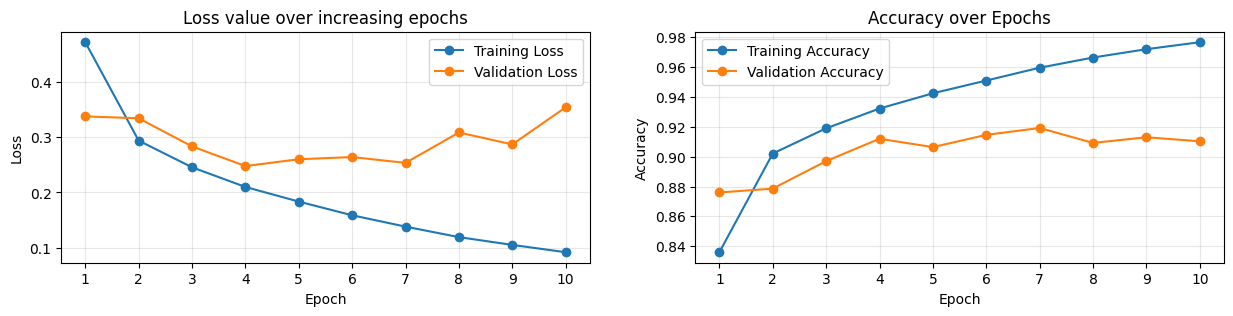

In [87]:
epochs = np.arange(training_epoch) + 1
plt.figure(figsize=(15, 3))
plt.subplot(121)
plt.title("Loss value over increasing epochs")
plt.plot(epochs, losses, marker='o', label="Training Loss")
plt.plot(epochs, val_losses, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(122)
plt.title("Accuracy over Epochs")
plt.plot(epochs, accuracies, marker='o', label="Training Accuracy")
plt.plot(epochs, val_accuracies, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

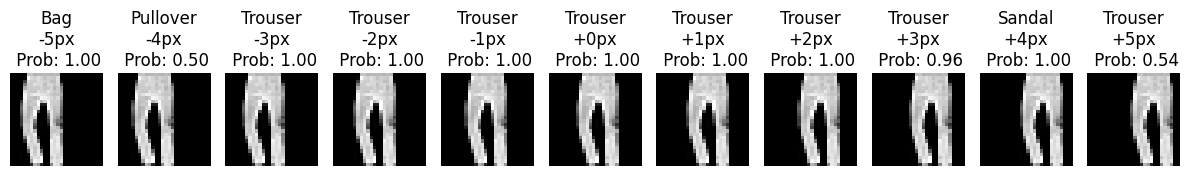

In [88]:
ix = 24300
fig, axes = plt.subplots(1, 11, figsize=(12, 2))
preds = []
for i, px in enumerate(range(-5, 6)):
    img, label = train[ix]
    img2 = torch.roll(img.view(28, 28), px, dims=1)
    img3 = img2.view(-1,1,28,28).to(device)
    np_output = model(img3).squeeze(0).cpu().detach().numpy()
    pred = np.exp(np_output) / np.sum(np.exp(np_output))
    preds.append(pred)
    axes[i].imshow(img2, cmap='gray')
    axes[i].set_title(f"{mnist_train.classes[pred.argmax()]}\n{px:+d}px\n Prob: {pred[pred.argmax()]:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

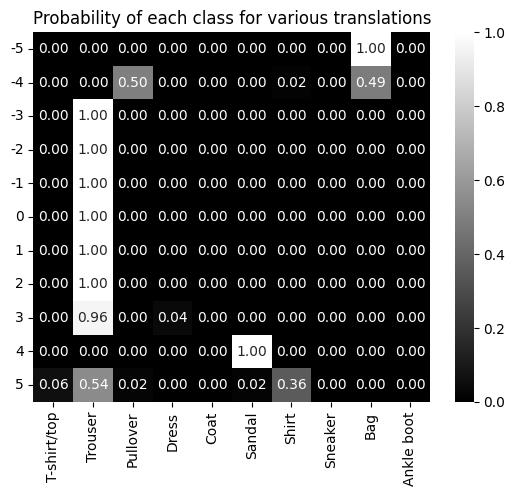

In [89]:
import seaborn as sns
ax = sns.heatmap(np.array(preds).reshape(11, 10), annot=True, fmt='.2f',
                 xticklabels=mnist_train.classes,
                 yticklabels=range(-5, 6),
                 cmap='gray')
ax.set_title('Probability of each class for various translations')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()